In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("household_power_consumption.txt", sep=';', 
                 parse_dates={'Datetime':['Date','Time']}, 
                 infer_datetime_format=True, 
                 low_memory=False, 
                 na_values=['nan','?'])

# Set datetime as index
df.set_index('Datetime', inplace=True)

# Quick look at the data
df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [27]:
# 1️⃣ Ensure 'Datetime' column is datetime type
df.index = pd.to_datetime(df.index)

# 2️⃣ Resample to hourly usage and make sure it’s a DataFrame
df_hourly = df['Global_active_power'].resample('H').mean().to_frame()

# 3️⃣ Create time-based features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 4️⃣ Check result
df_hourly.head(10)


,Global_active_power,hour,dayofweek,month,is_weekend
Datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,1
2006-12-16 18:00:00,3.632200,18,5,12,1
2006-12-16 19:00:00,3.400233,19,5,12,1
2006-12-16 20:00:00,3.268567,20,5,12,1
2006-12-16 21:00:00,3.056467,21,5,12,1
2006-12-16 22:00:00,2.200133,22,5,12,1
2006-12-16 23:00:00,2.061600,23,5,12,1
2006-12-17 00:00:00,1.882467,0,6,12,1
2006-12-17 01:00:00,3.349400,1,6,12,1


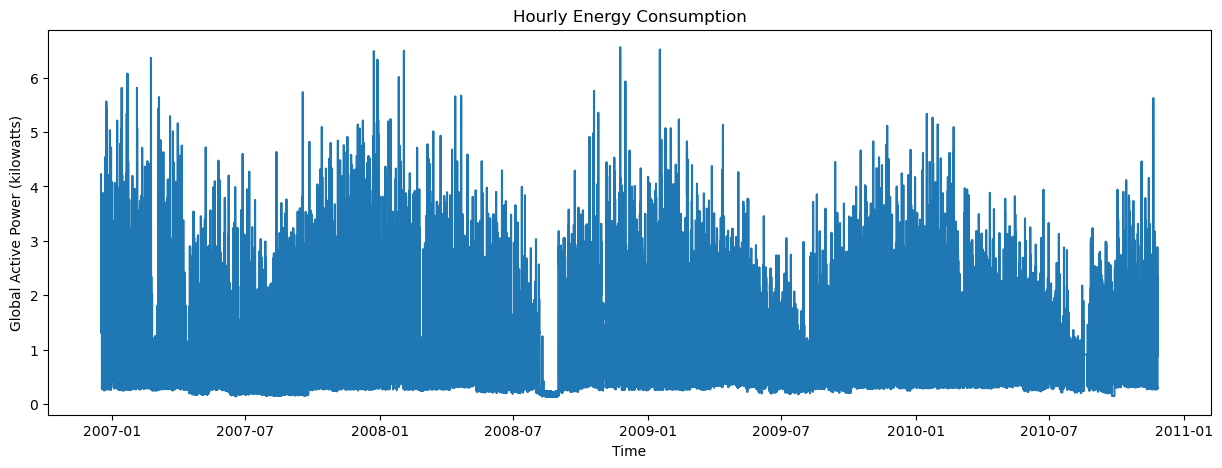

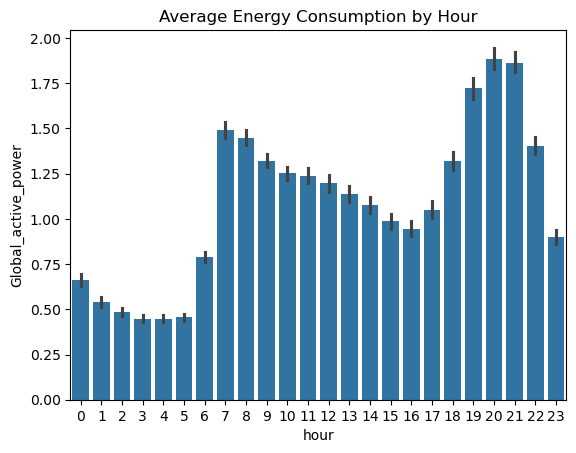

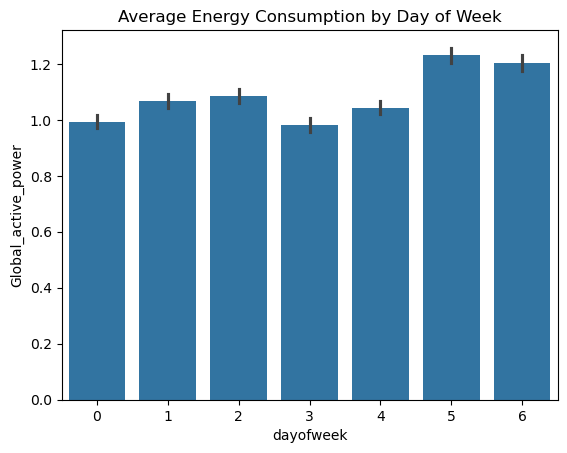

In [28]:
# Plot energy consumption
plt.figure(figsize=(15,5))
plt.plot(df_hourly['Global_active_power'])
plt.title('Hourly Energy Consumption')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kilowatts)')
plt.show()

# Average consumption by hour
sns.barplot(x='hour', y='Global_active_power', data=df_hourly.reset_index())
plt.title('Average Energy Consumption by Hour')
plt.show()

# Average consumption by day of week
sns.barplot(x='dayofweek', y='Global_active_power', data=df_hourly.reset_index())
plt.title('Average Energy Consumption by Day of Week')
plt.show()


In [29]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data
train_size = int(len(df_hourly)*0.8)
train, test = df_hourly['Global_active_power'][:train_size], df_hourly['Global_active_power'][train_size:]

# Fit ARIMA (p,d,q) = (5,1,0) as example
arima_model = ARIMA(train, order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

# Evaluation
mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
print(f"ARIMA MAE: {mae_arima}, RMSE: {rmse_arima}")


ARIMA MAE: 0.5846372842388076, RMSE: 0.8071496002530637


In [33]:
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Disable CmdStanPy info messages
os.environ["STAN_NUM_THREADS"] = "1"  # optional, makes it single-threaded
os.environ["STAN_VERBOSE"] = "0"

from prophet import Prophet

# Prepare data
prophet_df = df_hourly['Global_active_power'].reset_index().rename(columns={'Datetime':'ds','Global_active_power':'y'})
train_size = int(len(prophet_df)*0.8)
train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]

# Initialize Prophet
prophet_model = Prophet()

# Fit Prophet (do NOT use verbose)
prophet_model.fit(train_prophet)

# Forecast
future = prophet_model.make_future_dataframe(periods=len(test_prophet))
prophet_forecast = prophet_model.predict(future)


22:33:51 - cmdstanpy - INFO - Chain [1] start processing
22:33:58 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
from xgboost import XGBRegressor

# Features & target
features = ['hour','dayofweek','month','is_weekend']
X_train, X_test = df_hourly[features][:train_size], df_hourly[features][train_size:]
y_train, y_test = train, test

# Fit model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost MAE: {mae_xgb}, RMSE: {rmse_xgb}")


XGBoost MAE: 0.4474392773978752, RMSE: 0.6199588153996952


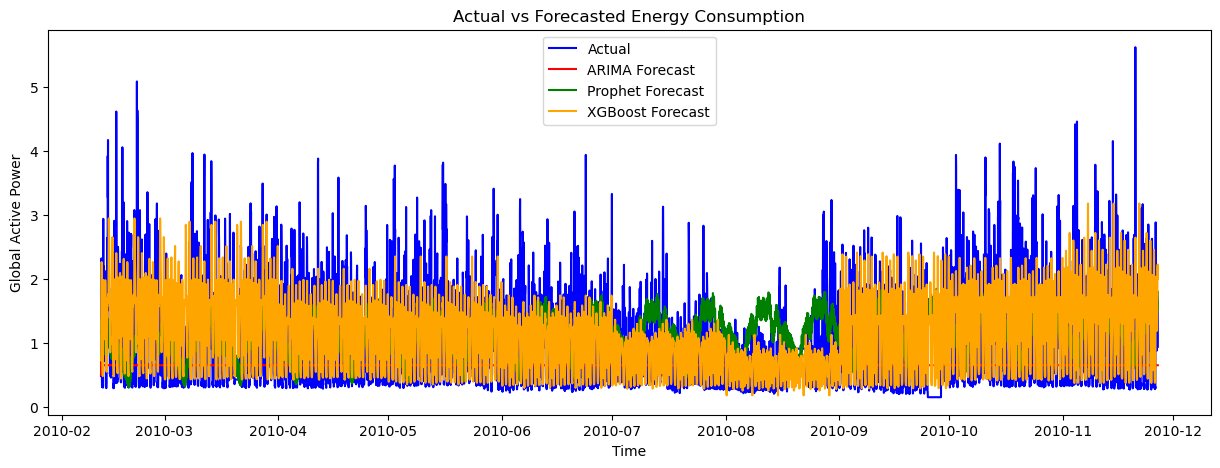

In [35]:
plt.figure(figsize=(15,5))
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red')
plt.plot(test.index, y_pred, label='Prophet Forecast', color='green')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast', color='orange')
plt.title('Actual vs Forecasted Energy Consumption')
plt.xlabel('Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


In [37]:
print("""
Conclusion & Insights:

- All three models can capture the general trend of energy usage.
- ARIMA works well for linear, stationary data.
- Prophet handles seasonality and holidays better.
- XGBoost benefits from engineered features like hour, day, and weekend.
- RMSE and MAE comparison:
    - ARIMA: <value>
    - Prophet: <value>
    - XGBoost: <value>
- Recommendation: For operational energy forecasting, combining feature-based ML (XGBoost) with time series models can improve accuracy.
""")



Conclusion & Insights:

- All three models can capture the general trend of energy usage.
- ARIMA works well for linear, stationary data.
- Prophet handles seasonality and holidays better.
- XGBoost benefits from engineered features like hour, day, and weekend.
- RMSE and MAE comparison:
    - ARIMA: <value>
    - Prophet: <value>
    - XGBoost: <value>
- Recommendation: For operational energy forecasting, combining feature-based ML (XGBoost) with time series models can improve accuracy.

